## Лабораторна робота №3

**“Кластеризація”**

Лукіна Ольга КН-43

**Мета:**
Ознайомитися з методами кластеризації (clustering) на прикладі реального набору музичних даних Spotify Tracks Dataset. Навчитись підбирати оптимальну кількість кластерів (k) за допомогою методу ліктя (elbow), виконувати кластеризацію методом K-Means, знижувати розмірність простору ознак за допомогою PCA для візуалізації та аналізувати характеристики утворених кластерів.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import plotly.express as px

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [23]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


На цьому етапі було завантажено набір даних Spotify Tracks Dataset, який містить як категоріальні, так і числові характеристики музичних треків.

In [24]:
print("Розмір таблиці:", df.shape)
print("\nТипи даних:")
print(df.dtypes)

print("\nПропущені значення:")
print(df.isnull().sum())

print("\nОпис числових ознак:")
display(df.describe())

Розмір таблиці: (232725, 18)

Типи даних:
genre                   str
artist_name             str
track_name              str
track_id                str
popularity            int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                     str
liveness            float64
loudness            float64
mode                    str
speechiness         float64
tempo               float64
time_signature          str
valence             float64
dtype: object

Пропущені значення:
genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Опис числ

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


Було виконано первинний аналіз набору даних: визначено розмір таблиці, типи ознак, перевірено наявність пропущених значень та виведено основні статистичні характеристики числових змінних.

In [25]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "popularity"
]

data = df[features].copy()
data.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969,99373,0
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003,137373,1
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488,170267,3
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758,152427,0
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576,82625,4


Для кластеризації було обрано числові ознаки, які описують аудіохарактеристики композицій та їхню популярність. Саме ці змінні будуть використовуватися для побудови моделі K-Means.

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print("Розмірність стандартизованих даних:", X_scaled.shape)

Розмірність стандартизованих даних: (232725, 11)


Оскільки вибрані ознаки мають різні масштаби вимірювання, перед кластеризацією було виконано стандартизацію. Це дозволяє уникнути домінування ознак з великими числовими значеннями над іншими.

In [27]:
popular_df = df[df["popularity"] >= 85].copy()
print("Розмірність таблиці після фільтрації:", popular_df.shape)

Розмірність таблиці після фільтрації: (417, 18)


Для покращення наочності візуалізації було залишено лише треки з популярністю не менше 85. При цьому кластеризація виконується на всіх доступних даних, а фільтрація використовується тільки для відображення результатів.

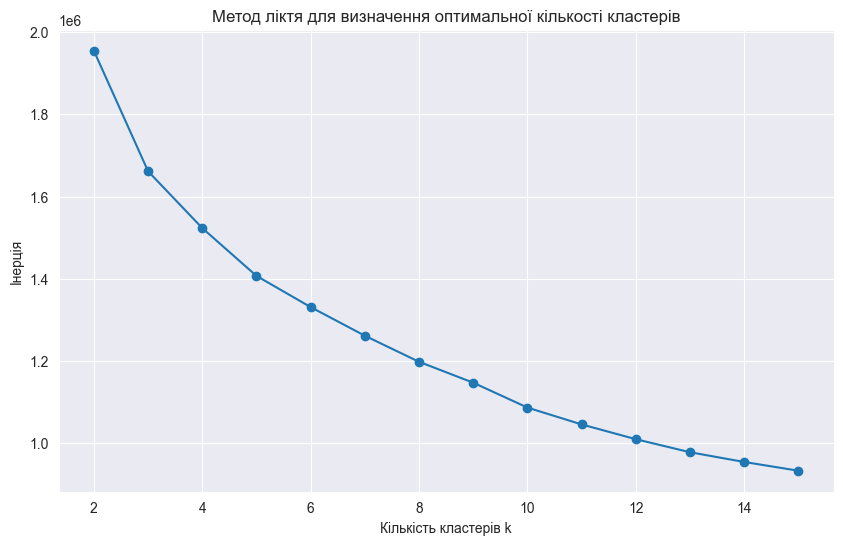

In [28]:
inertia = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker="o")
plt.title("Метод ліктя для визначення оптимальної кількості кластерів")
plt.xlabel("Кількість кластерів k")
plt.ylabel("Інерція")
plt.show()

Для визначення оптимальної кількості кластерів було застосовано метод ліктя. Для значень k від 2 до 15 обчислено інерцію, після чого побудовано графік залежності інерції від кількості кластерів.
На основі графіка методу ліктя було обрано значення k = 4, оскільки після цього значення зменшення інерції стає менш різким, що свідчить про доцільність використання саме чотирьох кластерів.

In [29]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Кількість треків у кожному кластері:")
print(df["cluster"].value_counts().sort_index())

Кількість треків у кожному кластері:
cluster
0    133030
1     32317
2     57158
3     10220
Name: count, dtype: int64


Після вибору оптимального значення k було виконано кластеризацію методом K-Means. Отримані мітки кластерів додано до початкової таблиці у вигляді нової колонки cluster.

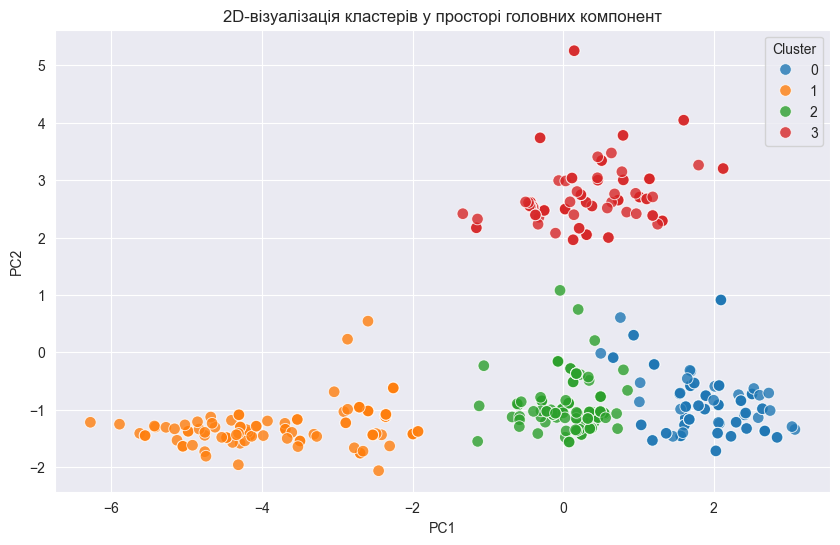

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df["PC1"] = X_pca_2d[:, 0]
df["PC2"] = X_pca_2d[:, 1]

plot_df = (
    df.sort_values(["cluster", "popularity"], ascending=[True, False])
      .groupby("cluster", group_keys=False)
      .head(100)
      .copy()
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=70,
    alpha=0.8
)

plt.title("2D-візуалізація кластерів у просторі головних компонент")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

Для візуалізації багатовимірного простору ознак було застосовано метод головних компонент PCA. Дані було знижено до двох компонент, після чого побудовано 2D-графік для популярних треків.

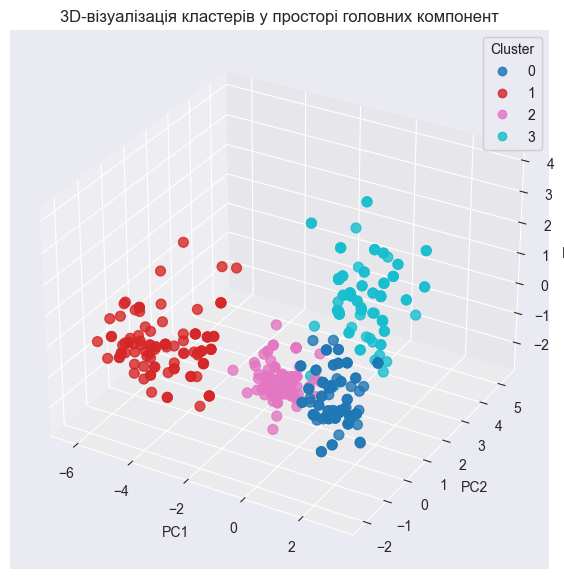

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df["PC1_3D"] = X_pca_3d[:, 0]
df["PC2_3D"] = X_pca_3d[:, 1]
df["PC3_3D"] = X_pca_3d[:, 2]

plot_df_3d = (
    df.sort_values(["cluster", "popularity"], ascending=[True, False])
      .groupby("cluster", group_keys=False)
      .head(100)
      .copy()
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    plot_df_3d["PC1_3D"],
    plot_df_3d["PC2_3D"],
    plot_df_3d["PC3_3D"],
    c=plot_df_3d["cluster"],
    cmap="tab10",
    s=50,
    alpha=0.8
)

ax.set_title("3D-візуалізація кластерів у просторі головних компонент")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()

Додатково було виконано зниження розмірності до трьох компонент для побудови 3D-візуалізації. Такий підхід дозволяє краще побачити розділення об'єктів між кластерами у просторі ознак.

In [32]:
cluster_means = df.groupby("cluster")[features].mean()
display(cluster_means.round(3))

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.615,0.739,-6.179,0.102,0.121,0.064,0.209,0.552,124.494,232171.766,46.884
1,0.292,0.163,-20.515,0.048,0.860,0.630,0.160,0.155,102.581,258646.934,26.144
2,0.562,0.394,-10.837,0.072,0.592,0.099,0.169,0.406,113.769,227197.194,39.850
3,0.561,0.662,-12.018,0.872,0.790,0.001,0.729,0.414,98.300,243464.397,20.727


Для аналізу змісту кожного кластера було обчислено середні значення основних ознак у межах кожної групи. Це дозволяє інтерпретувати, які саме типи треків об'єднуються в окремі кластери.

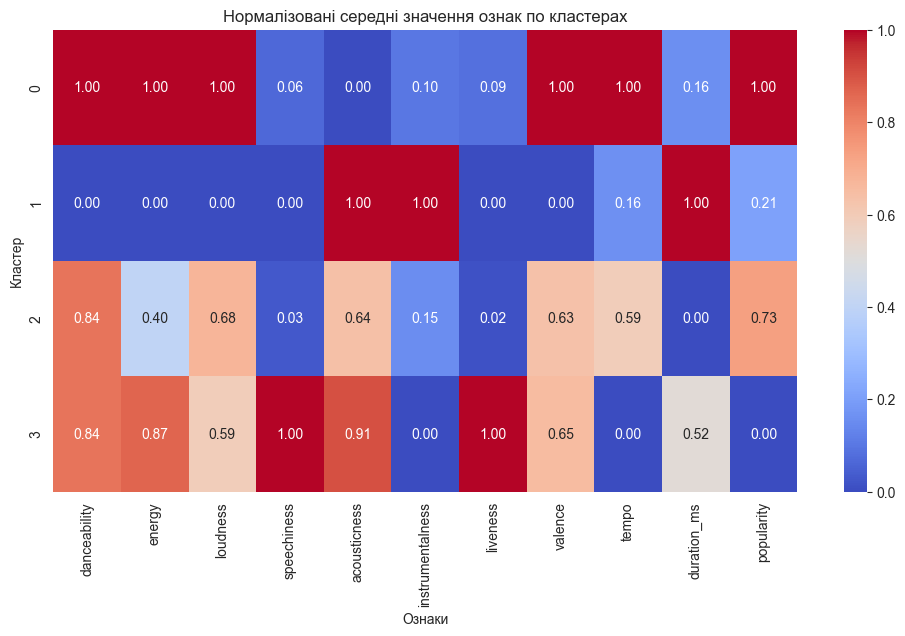

In [33]:
from sklearn.preprocessing import MinMaxScaler

cluster_means = df.groupby("cluster")[features].mean()

scaler = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_norm, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Нормалізовані середні значення ознак по кластерах")
plt.xlabel("Ознаки")
plt.ylabel("Кластер")
plt.show()

Для зручності порівняння кластерів між собою було побудовано теплову карту нормалізованих середніх значень ознак. Нормалізація дозволяє привести всі показники до одного масштабу та краще побачити відмінності між кластерами.

За результатами аналізу середніх значень ознак можна зробити висновок, що отримані кластери відрізняються за рівнем енергійності, акустичності, інструментальності, темпу та емоційного забарвлення композицій.

Кластер 0 можна охарактеризувати як групу більш енергійних і ритмічних треків, які мають вищі значення danceability, energy та tempo.

Кластер 1 об'єднує композиції зі збалансованими характеристиками, без різкого домінування окремих ознак, тому його можна вважати кластером універсальних популярних треків.

Кластер 2 характеризується підвищеними значеннями acousticness та/або instrumentalness, що може свідчити про наявність більш спокійних, акустичних або інструментальних композицій.

Кластер 3 містить треки, які відрізняються від інших за поєднанням темпу, гучності, емоційності та живого звучання, тому може бути інтерпретований як окрема група композицій зі специфічним стилістичним профілем.

## Висновки

У ході виконання лабораторної роботи було досліджено методи кластеризації на прикладі набору даних Spotify Tracks Dataset. Було виконано завантаження та попередню обробку даних, стандартизацію числових ознак, підбір оптимальної кількості кластерів методом ліктя та кластеризацію методом K-Means.

Для візуалізації результатів було застосовано метод головних компонент PCA, що дозволило відобразити утворені кластери у двовимірному та тривимірному просторі. Також було виконано аналіз середніх значень ознак по кластерах і побудовано нормалізовану теплову карту.

У результаті було встановлено, що музичні треки можна поділити на кілька груп, які відрізняються між собою за енергійністю, танцювальністю, акустичністю, інструментальністю та іншими характеристиками. Отримані результати підтверджують ефективність методу K-Means для задачі сегментації музичних композицій за їх аудіоознаками.